In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns
from helper_functions_iu import *
from quantify_perturbations import *

## Pre-process the objective values

In [2]:
obj_names = ['REL', 'RF', 'INPC', 'PFC', 'WCC']
util_abbrevs = ['W', 'D', 'F']

# append obj names to util_abbrevs
objs_utils = [f'{obj}_{util}' for util in util_abbrevs for obj in obj_names]
objs_regional =  [f'{obj}_R' for obj in obj_names]
objs_W = [f'{obj}_W' for obj in obj_names]
objs_D = [f'{obj}_D' for obj in obj_names]
objs_F = [f'{obj}_F' for obj in obj_names]
refset_name = 'IU'
sim_mode = 'p90'

'''
sim_mode_colors_coop = {'base_fb': "#6B8F71", 'base_sp': "#39563D",
                        'IU_fb': "#FBB13C", 'IU_sp': "#B66D0D"}
'''
sols_to_analyze = {'IU':[552, 260], 'base':[29]}  # sol indices for each refset
colors_per_sol = {'IU': ['#FBB13C', '#B66D0D'], 'base': ['#39563D']}
objs_original_df = pd.read_csv(f'objectives_{refset_name}_{sim_mode}_nd.csv', index_col=None, header=None)
objs_original_df.columns = objs_utils
objs_original_regional_df = find_regional_minimax(objs_original_df, obj_names)
objs_original_w_regional_df = pd.concat([objs_original_df, objs_original_regional_df], axis=1)


### Perform Delta-Moment Sensitivity Analysis

In [3]:
# for each solution, perform DMSA 
#for sol_num in range(0, objs_original_df.shape[0]):
for sol_num in sols_to_analyze[refset_name]:
    directory = f'perturbations_{refset_name}/sol{sol_num}_{refset_name}/'
    #directory = f'perturbations_{refset_name}/percent_degradation/'
    dv_arr = np.loadtxt(f'perturbations_{refset_name}/sol{sol_num}_{refset_name}/dvs_perturbations_{refset_name}_s{sol_num}.csv', delimiter=',')
    dv_names = ['RT_W', 'RT_D', 'RT_F', 'TT_D', 'TT_F', 'LMA_W', 'LMA_D', 'LMA_F', \
        'AP_W', 'AP_D', 'AP_F', 'IT_W', 'IT_D', 'IT_F', 'IP_W', 'IP_D', 'IP_F', \
        'INF_W', 'INF_D', 'INF_F', 'NRR_W', 'CRL', 'CRH', 'WR1', 'SCR', 'GQR', \
        'NRR_F', 'WR2_W', 'WR2_D', 'WR2_F']
    dv_names_selected = ['RT_W', 'RT_D', 'RT_F', 'TT_D', 'TT_F','INF_W', 'INF_D', 'INF_F']

    decvar_df = pd.DataFrame(dv_arr, columns=dv_names, index=None)
    decvar_df_selected = decvar_df[dv_names_selected]
    decvar_arr_selected = decvar_df_selected.to_numpy()

    cols_to_remove = check_dvs(decvar_df_selected)
    # if cols to remove is not empty, drop those columns
    if cols_to_remove:
        col_names_to_remove = [dv_names_selected[i] for i in cols_to_remove]
        decvar_df_selected.drop(columns=col_names_to_remove, inplace=True)
        decvar_arr_selected = decvar_df_selected.to_numpy()

    bounds = find_bounds(decvar_arr_selected)

    objs_perturbations = pd.read_csv(f'{directory}/objs_ptb_sim_{sim_mode}_sol{sol_num}.csv', index_col=None, header=None)
    #objs_perturbations = pd.read_csv(f'{directory}/sol{sol_num}_sim_{sim_mode}.csv', index_col=None, header=0)
    objs_perturbations.columns = objs_utils
    objs_perturbations_regional = find_regional_minimax(objs_perturbations, obj_names)
    objs_perturbations_w_regional = pd.concat([objs_perturbations, objs_perturbations_regional], axis=1)
    delta_sensitivity(decvar_df_selected, objs_perturbations_w_regional, sol_num, bounds, sim_mode, refset_name)
    

### Gather the SA results

In [4]:
#for sol_num in range(objs_original_df.shape[0]):
for sol_num in sols_to_analyze[refset_name]:
    gather_delta_results(sol_num, refset_name, sim_mode)

## Plot the SA results

### Plot relative sensitivity 

### Plot as bubble matrices 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# plot vertical bar chart of the sensitivity results 
utilities = ['_W', '_D', '_F']
util_dict = {'_W': 'Watertown', '_D': 'Dryville', '_F': 'Fallsland'}
objs = ['REL', 'RF', 'INPC', 'PFC', 'WCC']

def rotate_owners(owner_order, current_utility):
    idx = owner_order.index(current_utility)
    rotated = owner_order[idx:] + owner_order[:idx]
    return rotated

def plot_owner_bubble_matrix(ax, i, delta_long_df, current_utility, 
                             color_main, color_sec, objectives_order=None):
    df = delta_long_df.copy()

    suffix_map = {"_W": "Watertown", "_D": "Dryville", "_F": "Fallsland"}
    owner_order = ["Watertown", "Dryville", "Fallsland"]
    rotated_owners = rotate_owners(owner_order, current_utility)
    #base_palette = ["#415949", '#A4B494', '#739483']
    base_palette = [color_main, color_sec, color_sec]
    dark_primary_outline = "#141716"
    owner_rgb = dict(zip(rotated_owners, base_palette))

    # reorder the decision variables using the following list: 
    dv_order = ['RT_W', 'INF_W', 'RT_D', 'TT_D', 'INF_D', 'RT_F', 'TT_F', 'INF_F']

    df["Owner"] = df["DecisionVariable"].str[-2:].map(suffix_map)

    if objectives_order is None:
        # flip the order of objectives so that the first objective is on the left
        objectives_order = list(df["Objective"].unique())
    print("Objectives order:", objectives_order)

    x_map = {obj: i * 0.065 for i, obj in enumerate(objectives_order)}
    y_map = {dv: i * 0.075 for i, dv in enumerate(dv_order)}
    print("X map:", x_map)
    
    df["x"] = df["Objective"].map(x_map)
    df["y"] = df["DecisionVariable"].map(y_map)
    
    sens = df["Sensitivity"].to_numpy()
    #smax = sens.max() if sens.size else 1.0
    smax = 0.8 # use a fixed max for scaling to keep sizes comparable across utilities
    sizes = 80 + 1500 * (sens / (smax if smax else 1.0))  # scale size
    # = sens
    alpha = 1.0

    # Build per-point RGBA colors: owner color + per-point alpha
    rgba = []

    for o,a in zip(df["Owner"].astype(str).tolist(), [alpha]*len(df)):
        if o in owner_rgb:
            r, g, b = plt.matplotlib.colors.to_rgb(owner_rgb[o])
        else:
            r, g, b = (0.5, 0.5, 0.5)
        rgba.append((r, g, b, a))
    
    edge_colors = []
    primary_hex = color_main
    
    linewidths = []
    for o in df["Owner"].astype(str).tolist():
        if o in owner_rgb and owner_rgb[o] == primary_hex:
            edge_colors.append(dark_primary_outline)
            linewidths.append(0.1)
        else:
            edge_colors.append("white")
            linewidths.append(0.0)

    ax.scatter(df["x"], df["y"], s=sizes, c=rgba, edgecolors=edge_colors, linewidths=2)

    # label inside bubbles with sensitivity value
    for _, row in df.iterrows():
        if row["Sensitivity"] > 0:
            ax.text(
                row["x"],
                row["y"],
                f"{row['Sensitivity']:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                zorder=10
            )

    ax.set_xticks([x_map[obj] for obj in objectives_order])
    ax.set_xticklabels(objectives_order)

    ax.set_yticks([y_map[dv] for dv in dv_order])
    ax.set_yticklabels(dv_order, rotation=0, ha="right")
    ax.invert_yaxis()
    
    # Tight limits with small padding (helps "closer" feel)
    pad = 0.05
    ax.set_xlim(min(x_map.values()) - pad, max(x_map.values()) + pad)
    ax.set_ylim(min(y_map.values()) - pad, max(y_map.values()) + pad)

    ax.grid(False)
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # remove the ticks 
    ax.tick_params(left=False, bottom=True)

    ax.set_xlabel(f"{current_utility}'s Objectives")
    if i == 0:
        ax.set_ylabel("Decision Variable")

    # legend
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                          markerfacecolor=owner_rgb[o], markersize=10, label=o)
               for o in owner_order]
    # add two labels to show increasing size as increasing sensitivity 
    handles.append(plt.Line2D([0],[0], marker='o', color='w',
                          markerfacecolor='gray', markersize=10, label='Low Sensitivity to IU'))
    handles.append(plt.Line2D([0],[0], marker='o', color='w',
                          markerfacecolor='gray', markersize=20, label='High Sensitivity to IU')) 
    if i == 1:
        ax.legend(handles=handles, frameon=False, loc="lower center", bbox_to_anchor=(0.4, -0.25), ncol=5)
    ax.margins(x=0.0, y=0.0)


Objectives order: ['REL', 'RF', 'INPC', 'PFC', 'WCC']
X map: {'REL': 0.0, 'RF': 0.065, 'INPC': 0.13, 'PFC': 0.195, 'WCC': 0.26}
Objectives order: ['REL', 'RF', 'INPC', 'PFC', 'WCC']
X map: {'REL': 0.0, 'RF': 0.065, 'INPC': 0.13, 'PFC': 0.195, 'WCC': 0.26}
Objectives order: ['REL', 'RF', 'INPC', 'PFC', 'WCC']
X map: {'REL': 0.0, 'RF': 0.065, 'INPC': 0.13, 'PFC': 0.195, 'WCC': 0.26}


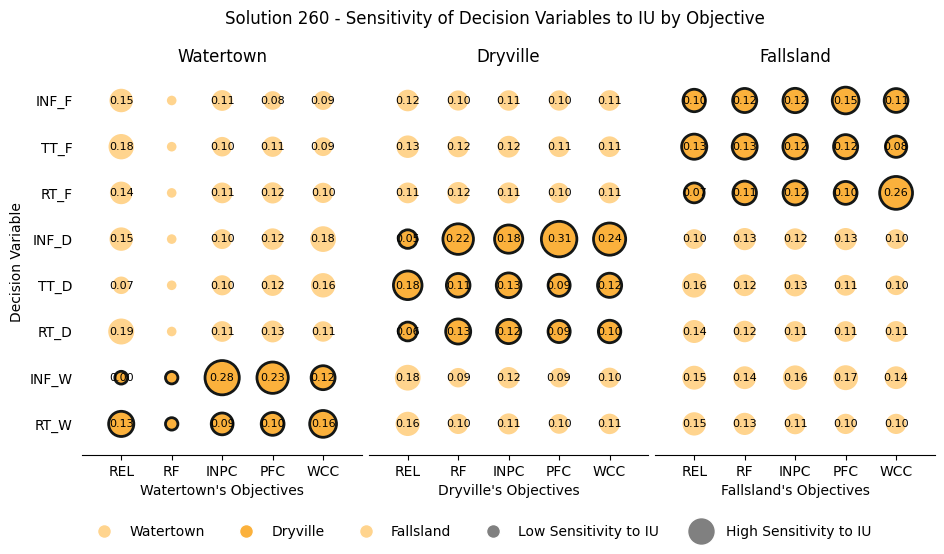

In [6]:
sol_num = 260

color_light_dict = {29: "#A8C4AC", 260: "#FFD48E", 552: "#EAB46C"} 
color_dark_dict = {29: "#39563D", 260: "#FBB13C", 552: "#B66D0D"}

'''
color_map = {
    'Baseline': sim_mode_colors_base.get('low-coop', '#3E8D8F'),
    'High-coop-407': sim_mode_colors_IU.get('high-coop-407', '#FBB13C'),
    'High-coop-129': sim_mode_colors_IU.get('high-coop-129', '#B66D0D'),
    'High-coop-579': sim_mode_colors_IU.get('high-coop-579', "#FF8847"),
}
'''

'''
sim_mode_colors_coop = {'base_pw': "#6B8F71", 'base_sp': "#39563D",
                        'IU_pw': "#FBB13C", 'IU_sp': "#B66D0D"}
'''
color_sec = color_light_dict[sol_num]
color_main = color_dark_dict[sol_num]

data_dir = f'perturbations_{refset_name}/sol{sol_num}_{refset_name}/'

grid_kws = {'width_ratios': [1,1,1], 'wspace': 0.025, 'height_ratios':[1], 'hspace':0.2}
fig_delta, axs_delta = plt.subplots(1,3, figsize=(11,5), gridspec_kw=grid_kws, sharey=True)

for i, util in enumerate(utilities):
    '''
    PROCESS DATA FOR TREEMAP
    '''
    # add horizontal grid lines behind bars
    axs_u = axs_delta[i]
    # each row is an objective, and each column is a decision variable
    delta_df = pd.read_csv(
        f'{data_dir}delta_dv_objs{util}_{refset_name}_{sim_mode}.csv',
        index_col=None,
        header=0
    )
    
    delta_df.index = objs
    # reverse the order of the rows so that the first objective is at the top

    objectives = delta_df.index.tolist()
    # normalize each row by the sum of absolute sensitivities in that row
    row_sums = delta_df.abs().sum(axis=1)
    delta_df = delta_df.div(row_sums, axis=0).fillna(0)

    delta_df.insert(0, "Objective", objectives)
    
    delta_long_df = delta_df.melt(
        id_vars=["Objective"],
        var_name="DecisionVariable",
        value_name="Sensitivity"
    )

    delta_long_df.insert(0, "Utility", util)
    plot_owner_bubble_matrix(axs_u, i, delta_long_df, util_dict[util], color_main, color_sec, 
                             objectives_order=['REL', 'RF', 'INPC', 'PFC', 'WCC'])
    axs_u.set_title(f'{util_dict[util]}')

#plt.tight_layout()
plt.suptitle(f'Solution {sol_num} - Sensitivity of Decision Variables to IU by Objective', y=1.0)
plt.savefig(f'figures/delta_results/bubble_sensitivity_sol{sol_num}_{refset_name}_{sim_mode}_top3.pdf', bbox_inches='tight', dpi=300)
plt.show()